imports loading dataset

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
df = pd.read_csv("../data/raw/data.csv")

dataset overview how many rows,columns what those column are their data types and statstics

In [15]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


missing values and visualization

In [16]:
df.isnull().sum()
(df.isnull().sum()
 .sort_values(ascending=False)
 .head(20))

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

numerical feature distribution(amount and value columns)

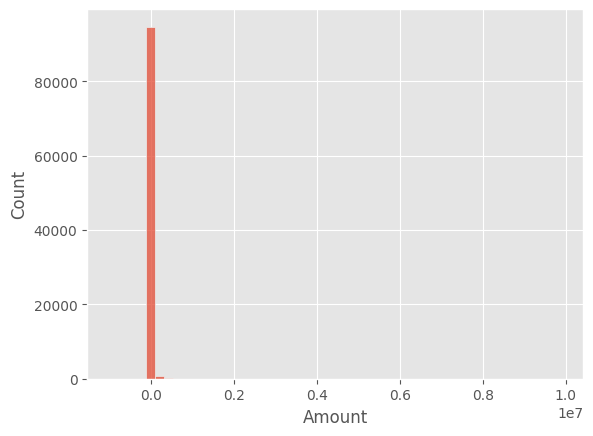

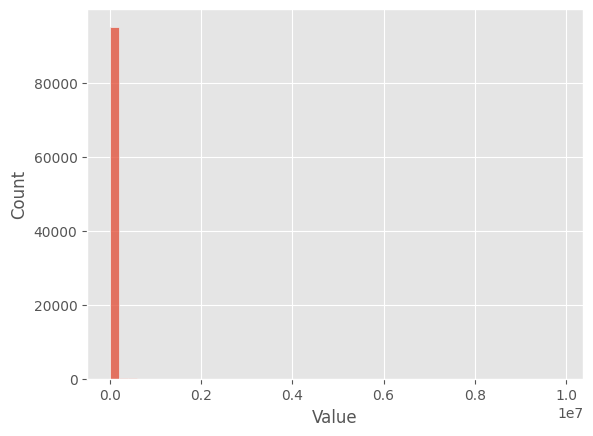

In [17]:
sns.histplot(df["Amount"], bins=50)
plt.show()
sns.histplot(df["Value"], bins=50)
plt.show()

categorical features (product)

In [18]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

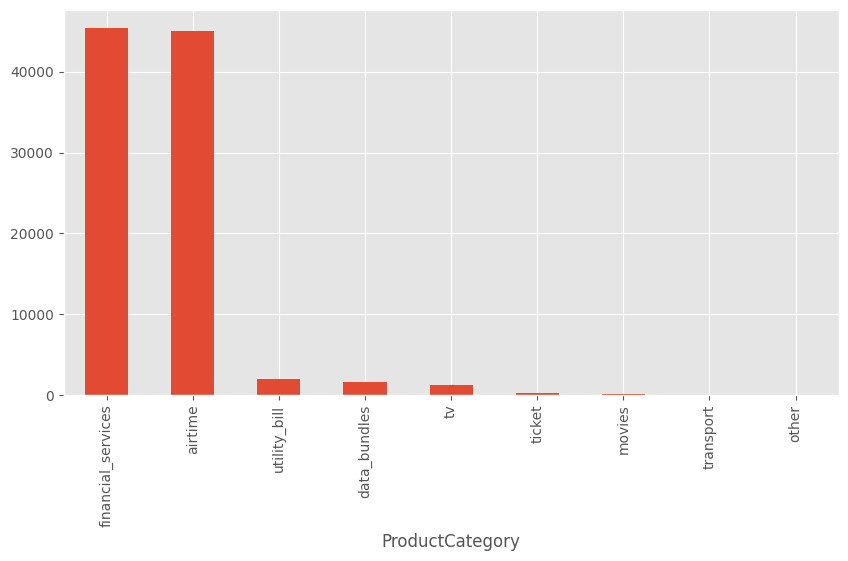

In [19]:
df["ProductCategory"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)
plt.show()

channel 

In [20]:
df["ChannelId"].value_counts()


ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

Insight 1: Most Customers Use Only Two Channels

 result:

ChannelId_3 → 56,935
ChannelId_2 → 37,141

Business Interpretation
The vast majority of transactions occur through ChannelId_3 and ChannelId_2.

 provider

In [21]:
df["ProviderId"].value_counts()

ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

Insight 2: Transactions Are Concentrated Among a Few Providers

 result:

ProviderId_4 → 38,189
ProviderId_6 → 34,186
ProviderId_5 → 14,542

Business Interpretation
Most transactions are processed through a small number of providers, particularly ProviderId_4 and ProviderId_6.

fraud analysis

In [22]:
df["FraudResult"].value_counts()
df["FraudResult"].value_counts(normalize=True)*100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

insight 3: Fraud Transactions Are Extremely Rare
 result:

Fraud = 0 → 99.80%
Fraud = 1 → 0.20%

Business Interpretation
The dataset is highly imbalanced, with only about 0.2% of transactions labeled as fraudulent. This means fraudulent activity is very uncommon compared to legitimate transactions.

corelation analysis heatmap

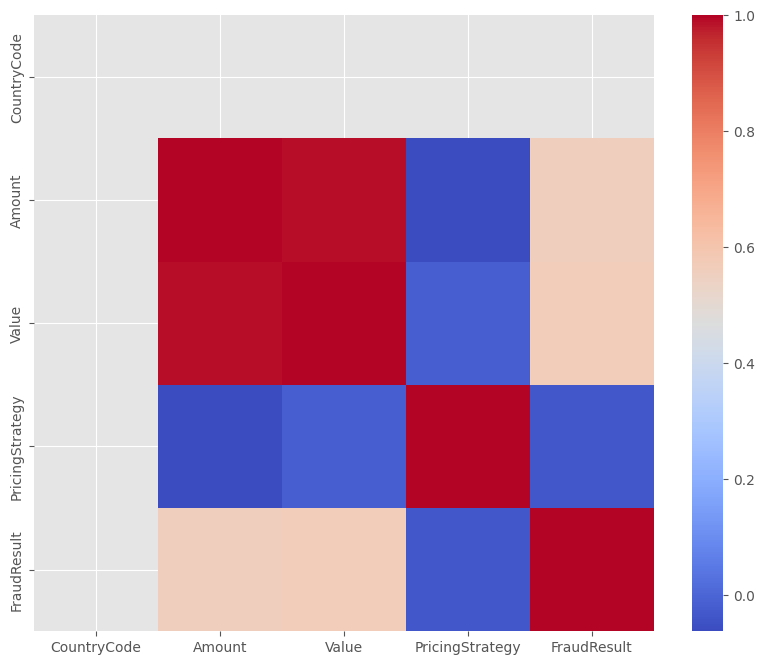

In [23]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.show()

outlier detection (amount and value)

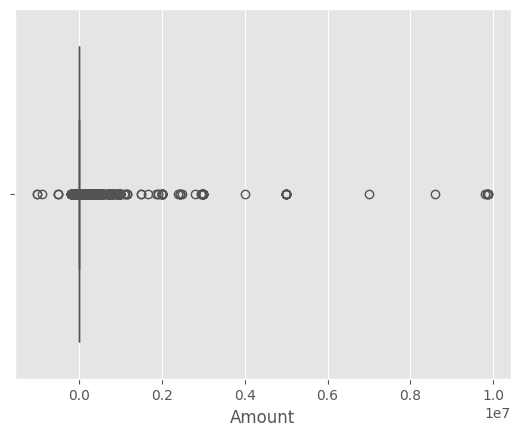

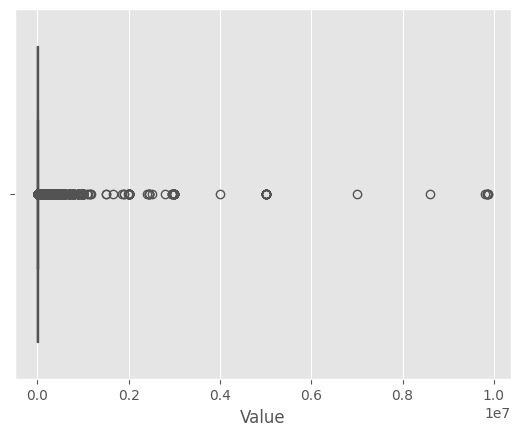

In [24]:
sns.boxplot(x=df["Amount"])
plt.show()
sns.boxplot(x=df["Value"])
plt.show()

Time-Based Analysis transaction per month

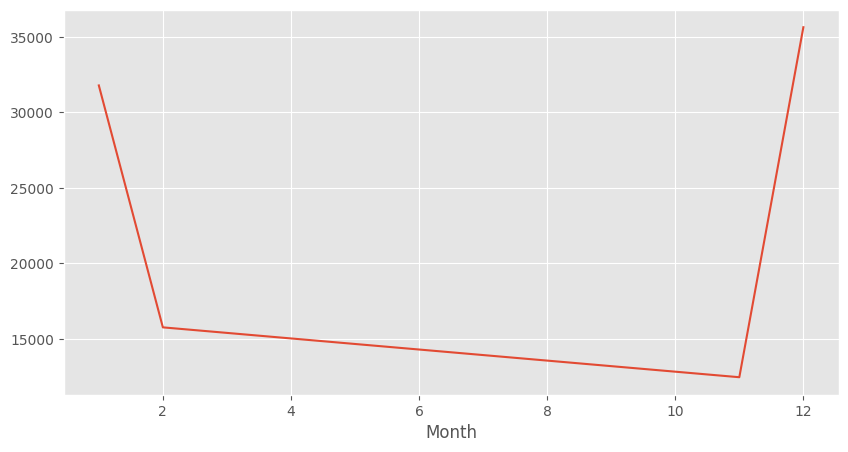

In [25]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)
df["Month"] = (
    df["TransactionStartTime"]
    .dt.month
)
monthly = df.groupby("Month").size()

monthly.plot(
    figsize=(10,5)
)
plt.show()

 Key Insights

1. Transaction amounts exhibit significant skewness and outliers, indicating the need for scaling or transformation during modeling.

2. Customer transaction behavior varies across product categories and time periods, providing valuable signals for credit risk prediction.

3.Correlation Findings
Amount and Value are almost perfectly correlated
Business interpretation:
These two variables contain nearly the same information.

4. PricingStrategy shows very weak relationships

PricingStrategy appears close to zero correlation with most numerical variables.

Business interpretation:

Pricing strategy alone may not strongly explain transaction value or fraud occurrence.

5,CountryCode contains no variability and is unlikely to contribute to prediction.